# Phase III Geometry Comparison: 17 x 17, Re = 10

This notebook compares lid-driven cavity solutions for three cavity geometries on the same `17 x 17` mesh:

| Case | Width (m) | Height (m) | Aspect ratio `width:height` |
|---|---:|---:|---:|
| Square reference | 0.05 | 0.05 | 1:1 |
| Wide cavity | 0.10 | 0.05 | 2:1 |
| Tall cavity | 0.05 | 0.10 | 1:2 |

The solver is patched in memory, so `main_solver.py` is not modified. Results are cached after each case, and the plotting cells generate centerline profiles plus `u`, `v`, and pressure contours for each geometry.

In [1]:
from pathlib import Path
import contextlib
import io
import json
import os
import shutil
import time

from IPython.display import Markdown, display
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

if Path.cwd().name != "start-code" and (Path.cwd() / "start-code").exists():
    os.chdir(Path.cwd() / "start-code")

plot_dir = Path("Phase III Geometry Comparison 17x17")
plot_dir.mkdir(exist_ok=True)

cache_dir = plot_dir / "case_cache"
cache_dir.mkdir(exist_ok=True)

print(f"Working directory: {Path.cwd()}")
print(f"Plot output directory: {plot_dir.resolve()}")
print(f"Cache directory: {cache_dir.resolve()}")

Working directory: /Users/windy/mae4100-courseproject2/start-code
Plot output directory: /Users/windy/mae4100-courseproject2/start-code/Phase III Geometry Comparison 17x17
Cache directory: /Users/windy/mae4100-courseproject2/start-code/Phase III Geometry Comparison 17x17/case_cache


In [2]:
NODE_COUNT = 17
REYNOLDS_NUMBER = 10.0
CFL = 0.5
KAPPA = 0.5
C4 = 0.01
TOLERANCE = 1e-8
MAX_ITERATIONS = None

GEOMETRY_CASES = [
    {"name": "Square reference", "label": "square_1to1", "width": 0.05, "height": 0.05, "aspect": "1:1"},
    {"name": "Wide cavity", "label": "wide_2to1", "width": 0.10, "height": 0.05, "aspect": "2:1"},
    {"name": "Tall cavity", "label": "tall_1to2", "width": 0.05, "height": 0.10, "aspect": "1:2"},
]

USE_CACHE = True
FORCE_RERUN = False

pd.DataFrame([
    {
        "case": case["name"],
        "nodes": f"{NODE_COUNT}x{NODE_COUNT}",
        "Re": REYNOLDS_NUMBER,
        "width (m)": case["width"],
        "height (m)": case["height"],
        "aspect width:height": case["aspect"],
        "dx (m)": case["width"] / (NODE_COUNT - 1),
        "dy (m)": case["height"] / (NODE_COUNT - 1),
    }
    for case in GEOMETRY_CASES
])

,case,nodes,Re,width (m),height (m),aspect width:height,dx (m),dy (m)
0,Square reference,17x17,10.0,0.05,0.05,1:1,0.003125,0.003125
1,Wide cavity,17x17,10.0,0.10,0.05,2:1,0.006250,0.003125
2,Tall cavity,17x17,10.0,0.05,0.10,1:2,0.003125,0.006250


In [3]:
MAIN_PLOT_FILES = [
    "ucontour.png",
    "vcontour.png",
    "pcontour.png",
    "residualcomponent.png",
    "residual.png",
]


def format_solver_float(value):
    return f"{value:<16g}"


def apply_replacements(source, replacements, solver_path):
    for old, new in replacements.items():
        if old not in source:
            raise RuntimeError(f"Could not find expected setting in {solver_path}: {old}")
        source = source.replace(old, new, 1)
    return source


def patched_solver_source(case):
    solver_path = Path("main_solver.py")
    source = solver_path.read_text()

    replacements = {
        "imax = 9               # Number of points in the x-direction (use odd numbers only)":
            f"imax = {NODE_COUNT:<15}# Number of points in the x-direction (use odd numbers only)",
        "jmax = 9               # Number of points in the y-direction (use odd numbers only)":
            f"jmax = {NODE_COUNT:<15}# Number of points in the y-direction (use odd numbers only)",
        "xmax = 0.05            # Maximum x location (m)":
            f"xmax = {format_solver_float(case['width'])}# Maximum x location (m)",
        "ymax = 0.05            # Maximum y location (m)":
            f"ymax = {format_solver_float(case['height'])}# Maximum y location (m)",
        "iterout = 5000         # Number of time steps between solution output":
            "iterout = 100000000    # Number of time steps between solution output",
        "cfl = 0.5              # CFL number used to determine time step":
            f"cfl = {format_solver_float(CFL)}# CFL number used to determine time step",
        "Cx = 0.01              # Parameter for 4th order artificial viscosity in x":
            f"Cx = {format_solver_float(C4)}# Parameter for 4th order artificial viscosity in x",
        "Cy = 0.01              # Parameter for 4th order artificial viscosity in y":
            f"Cy = {format_solver_float(C4)}# Parameter for 4th order artificial viscosity in y",
        "toler = 1e-10          # Tolerance for iterative residual convergence":
            f"toler = {format_solver_float(TOLERANCE)}# Tolerance for iterative residual convergence",
        "rkappa = 0.5           # Time derivative preconditioning constant":
            f"rkappa = {format_solver_float(KAPPA)}# Time derivative preconditioning constant",
        "Re = 10.0              # Reynolds number = rho*Uinf*L/rmu":
            f"Re = {format_solver_float(REYNOLDS_NUMBER)}# Reynolds number = rho*Uinf*L/rmu",
        "vectorize = False":
            "vectorize = True",
        "u = SGS_forward_sweep(u, uold, dt, s, rho, rhoinv, dx, dy, rkappa, rmu, vel2ref, artviscx, artviscy)":
            "u = SGS_forward_sweep_acc(u, uold, dt, s, rho, rhoinv, dx, dy, rkappa, rmu, vel2ref, artviscx, artviscy)",
        "u = SGS_backward_sweep(u, uold, dt, s, rho, rhoinv, dx, dy, rkappa, rmu, vel2ref, artviscx, artviscy)":
            "u = SGS_backward_sweep_acc(u, uold, dt, s, rho, rhoinv, dx, dy, rkappa, rmu, vel2ref, artviscx, artviscy)",
    }

    if MAX_ITERATIONS is not None:
        replacements["nmax = 500000          # Maximum number of iterations"] = (
            f"nmax = {MAX_ITERATIONS:<15}# Maximum number of iterations"
        )

    return solver_path, apply_replacements(source, replacements, solver_path)


def archive_solver_plots(label):
    case_plot_dir = plot_dir / label
    case_plot_dir.mkdir(exist_ok=True)
    for filename in MAIN_PLOT_FILES:
        src = Path(filename)
        if src.exists():
            dst = case_plot_dir / filename
            if dst.exists():
                dst.unlink()
            shutil.move(str(src), str(dst))


def cache_paths(case):
    label = case["label"]
    return cache_dir / f"{label}.npz", cache_dir / f"{label}.json"


def save_case_cache(case, result):
    npz_path, json_path = cache_paths(case)
    np.savez_compressed(
        npz_path,
        u=result["u"],
        conv_history=result["conv_history"],
        residual_history=result["residual_history"],
        final_residual=result["final_residual"],
        x=result["x"],
        y=result["y"],
    )
    metadata = {
        key: value
        for key, value in result.items()
        if key not in {"u", "conv_history", "residual_history", "final_residual", "x", "y", "captured_output"}
    }
    metadata["captured_output_tail"] = result["captured_output"].splitlines()[-12:]
    json_path.write_text(json.dumps(metadata, indent=2))


def load_case_cache(case):
    npz_path, json_path = cache_paths(case)
    if not npz_path.exists() or not json_path.exists():
        return None

    arrays = np.load(npz_path)
    metadata = json.loads(json_path.read_text())
    metadata.update({
        "u": arrays["u"],
        "conv_history": arrays["conv_history"],
        "residual_history": arrays["residual_history"],
        "final_residual": arrays["final_residual"],
        "x": arrays["x"],
        "y": arrays["y"],
        "captured_output": "\n".join(metadata.pop("captured_output_tail", [])),
    })
    return metadata


def run_geometry_case(case):
    cached = load_case_cache(case) if USE_CACHE and not FORCE_RERUN else None
    if cached is not None:
        print(f"Loaded cached result for {case['label']}")
        return cached

    solver_path, source = patched_solver_source(case)
    namespace = {
        "__file__": str(solver_path.resolve()),
        "__name__": "__main__",
    }

    print(
        f"Running {case['name']}: {NODE_COUNT}x{NODE_COUNT}, "
        f"Re={REYNOLDS_NUMBER:g}, width={case['width']}, height={case['height']}"
    )
    start_time = time.perf_counter()
    with contextlib.redirect_stdout(io.StringIO()) as captured_output:
        exec(compile(source, str(solver_path), "exec"), namespace)
    elapsed_time = time.perf_counter() - start_time

    archive_solver_plots(case["label"])
    plt.close("all")

    u = namespace["u"].copy()
    imax, jmax, _ = u.shape
    x_coords = np.linspace(namespace["xmin"], namespace["xmax"], imax)
    y_coords = np.linspace(namespace["ymin"], namespace["ymax"], jmax)

    result = {
        "name": case["name"],
        "label": case["label"],
        "aspect": case["aspect"],
        "nodes": NODE_COUNT,
        "Re": REYNOLDS_NUMBER,
        "CFL": CFL,
        "kappa": KAPPA,
        "C4": C4,
        "tolerance": TOLERANCE,
        "width": float(namespace["xmax"] - namespace["xmin"]),
        "height": float(namespace["ymax"] - namespace["ymin"]),
        "dx": float(namespace["dx"]),
        "dy": float(namespace["dy"]),
        "viscosity": float(namespace["rmu"]),
        "iterations": int(namespace["n"]),
        "converged": bool(namespace["isConverged"]),
        "final_conv": float(namespace["conv"]),
        "elapsed_time_sec": float(elapsed_time),
        "x": x_coords,
        "y": y_coords,
        "u": u,
        "final_residual": np.array(namespace["res"], copy=True),
        "conv_history": np.array(namespace["convVector"], copy=True),
        "residual_history": np.array(namespace["resPMatrix"], copy=True),
        "captured_output": captured_output.getvalue(),
    }
    save_case_cache(case, result)
    return result


def build_summary(results):
    return pd.DataFrame([
        {
            "case": result["name"],
            "nodes": f"{result['nodes']}x{result['nodes']}",
            "Re": result["Re"],
            "width (m)": result["width"],
            "height (m)": result["height"],
            "aspect width:height": result["aspect"],
            "dx (m)": result["dx"],
            "dy (m)": result["dy"],
            "viscosity (N*s/m^2)": result["viscosity"],
            "iterations": result["iterations"],
            "converged": result["converged"],
            "final conv": result["final_conv"],
            "wall time (s)": result["elapsed_time_sec"],
        }
        for result in results
    ])

In [4]:
results = []
for case in GEOMETRY_CASES:
    result = run_geometry_case(case)
    results.append(result)

summary = build_summary(results)
summary.to_csv(plot_dir / "geometry_summary.csv", index=False)
summary

Running Square reference: 17x17, Re=10, width=0.05, height=0.05
Running Wide cavity: 17x17, Re=10, width=0.1, height=0.05
Running Tall cavity: 17x17, Re=10, width=0.05, height=0.1


,case,nodes,Re,width (m),height (m),aspect width:height,dx (m),dy (m),viscosity (N*s/m^2),iterations,converged,final conv,wall time (s)
0,Square reference,17x17,10.0,0.05,0.05,1:1,0.003125,0.003125,0.005,1573,True,9.787253e-09,9.385999
1,Wide cavity,17x17,10.0,0.10,0.05,2:1,0.006250,0.003125,0.010,5763,True,9.989734e-09,28.206480
2,Tall cavity,17x17,10.0,0.05,0.10,1:2,0.003125,0.006250,0.005,1566,True,9.927906e-09,8.269933


In [5]:
# Use this cell if you reopen the notebook and want to load cached data without rerunning the solver.
if "results" not in globals() or len(results) == 0:
    results = []
    for case in GEOMETRY_CASES:
        cached = load_case_cache(case)
        if cached is None:
            raise FileNotFoundError(f"No cached result found for {case['label']}. Run the solver cell first.")
        results.append(cached)

summary = build_summary(results)
display(summary)

,case,nodes,Re,width (m),height (m),aspect width:height,dx (m),dy (m),viscosity (N*s/m^2),iterations,converged,final conv,wall time (s)
0,Square reference,17x17,10.0,0.05,0.05,1:1,0.003125,0.003125,0.005,1573,True,9.787253e-09,9.385999
1,Wide cavity,17x17,10.0,0.10,0.05,2:1,0.006250,0.003125,0.010,5763,True,9.989734e-09,28.206480
2,Tall cavity,17x17,10.0,0.05,0.10,1:2,0.003125,0.006250,0.005,1566,True,9.927906e-09,8.269933


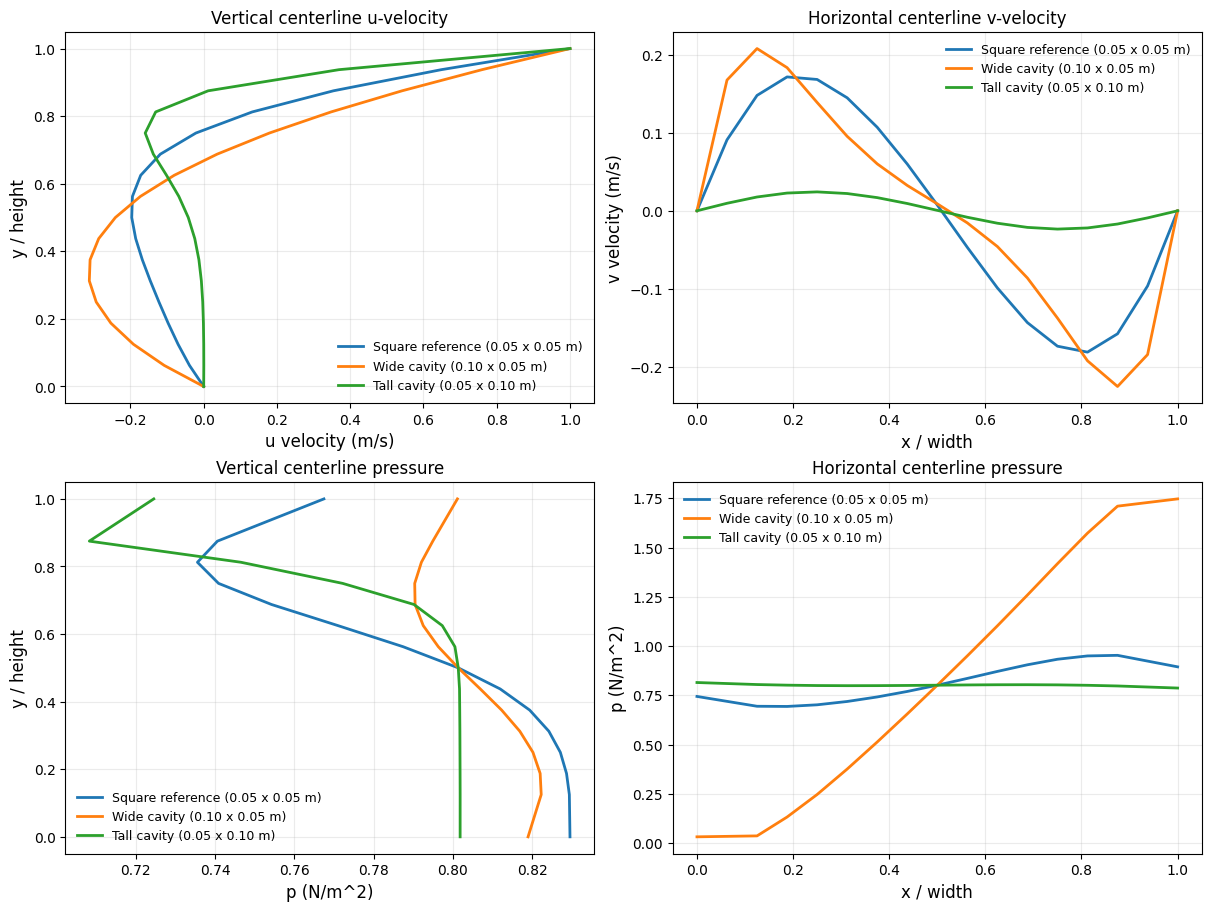

In [6]:
def center_indices(result):
    imax, jmax, _ = result["u"].shape
    return (imax - 1) // 2, (jmax - 1) // 2


fontsize = 12
fig, axes = plt.subplots(2, 2, figsize=(12, 9), constrained_layout=True)

for result in results:
    i_mid, j_mid = center_indices(result)
    u = result["u"]
    x_norm = result["x"] / result["width"]
    y_norm = result["y"] / result["height"]
    label = f"{result['name']} ({result['width']:.2f} x {result['height']:.2f} m)"

    axes[0, 0].plot(u[i_mid, :, 1], y_norm, linewidth=2, label=label)
    axes[0, 1].plot(x_norm, u[:, j_mid, 2], linewidth=2, label=label)
    axes[1, 0].plot(u[i_mid, :, 0], y_norm, linewidth=2, label=label)
    axes[1, 1].plot(x_norm, u[:, j_mid, 0], linewidth=2, label=label)

axes[0, 0].set_xlabel("u velocity (m/s)", fontsize=fontsize)
axes[0, 0].set_ylabel("y / height", fontsize=fontsize)
axes[0, 0].set_title("Vertical centerline u-velocity", fontsize=fontsize)

axes[0, 1].set_xlabel("x / width", fontsize=fontsize)
axes[0, 1].set_ylabel("v velocity (m/s)", fontsize=fontsize)
axes[0, 1].set_title("Horizontal centerline v-velocity", fontsize=fontsize)

axes[1, 0].set_xlabel("p (N/m^2)", fontsize=fontsize)
axes[1, 0].set_ylabel("y / height", fontsize=fontsize)
axes[1, 0].set_title("Vertical centerline pressure", fontsize=fontsize)

axes[1, 1].set_xlabel("x / width", fontsize=fontsize)
axes[1, 1].set_ylabel("p (N/m^2)", fontsize=fontsize)
axes[1, 1].set_title("Horizontal centerline pressure", fontsize=fontsize)

for ax in axes.flat:
    ax.grid(True, alpha=0.25)
    ax.legend(loc="best", fontsize=9, frameon=False)

plt.savefig(plot_dir / "geometry_centerline_profiles.png", dpi=300)
plt.show()

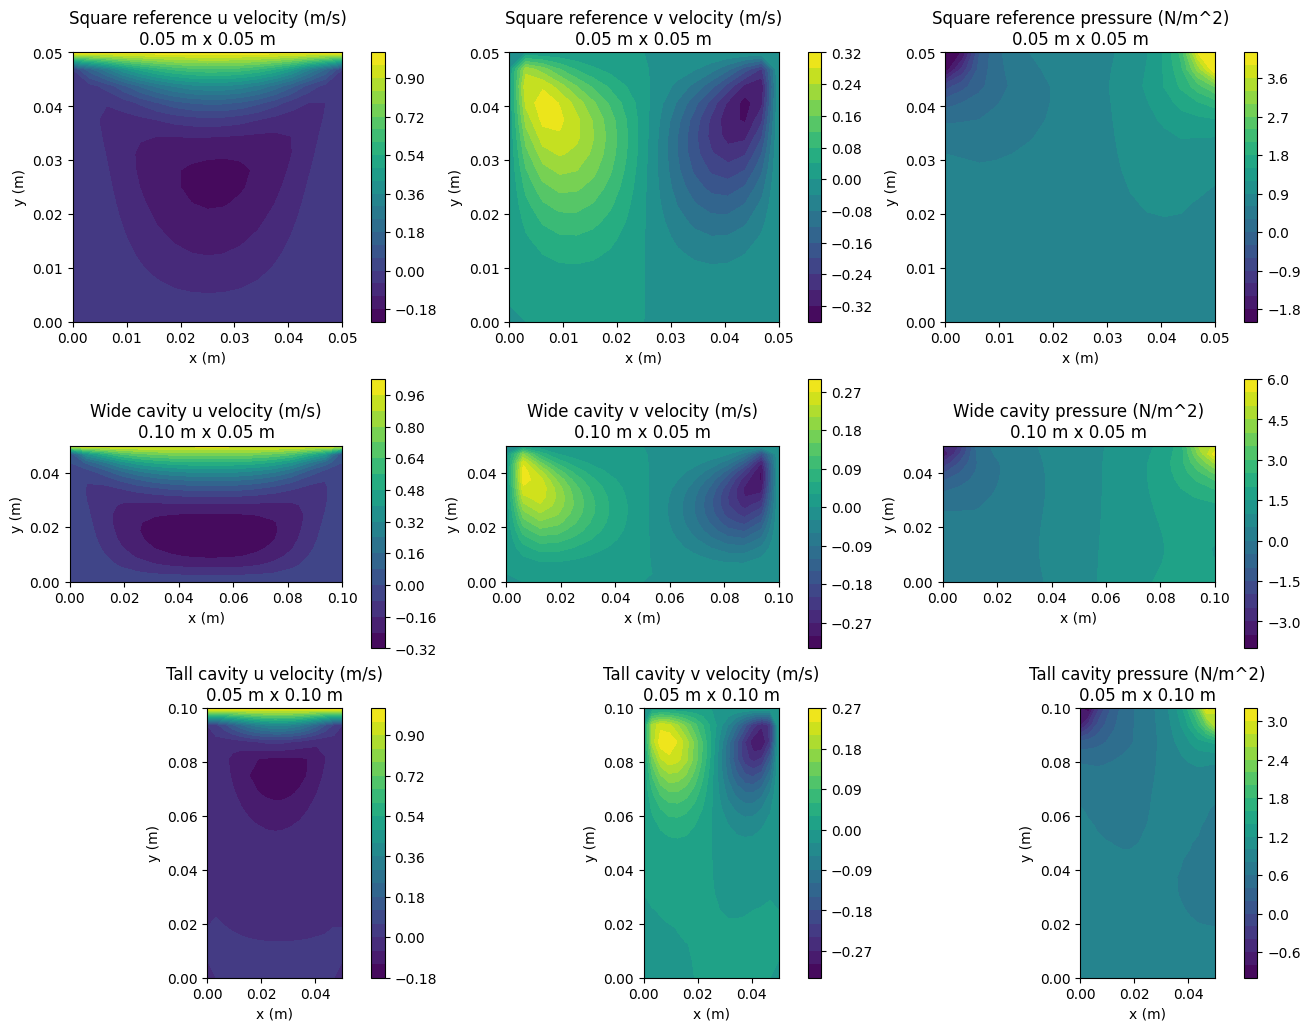

In [7]:
fig, axes = plt.subplots(len(results), 3, figsize=(13, 3.4 * len(results)), constrained_layout=True)

if len(results) == 1:
    axes = np.array([axes])

for row, result in enumerate(results):
    X, Y = np.meshgrid(result["x"], result["y"], indexing="ij")
    u = result["u"]
    fields = [
        (u[:, :, 1], "u velocity (m/s)", "u"),
        (u[:, :, 2], "v velocity (m/s)", "v"),
        (u[:, :, 0], "pressure (N/m^2)", "p"),
    ]

    for col, (field, title, short_name) in enumerate(fields):
        ax = axes[row, col]
        contour = ax.contourf(X, Y, field, levels=20)
        fig.colorbar(contour, ax=ax)
        ax.set_aspect("equal")
        ax.set_xlabel("x (m)")
        ax.set_ylabel("y (m)")
        ax.set_title(
            f"{result['name']} {title}\n"
            f"{result['width']:.2f} m x {result['height']:.2f} m"
        )

plt.savefig(plot_dir / "geometry_contour_comparison.png", dpi=300)
plt.show()

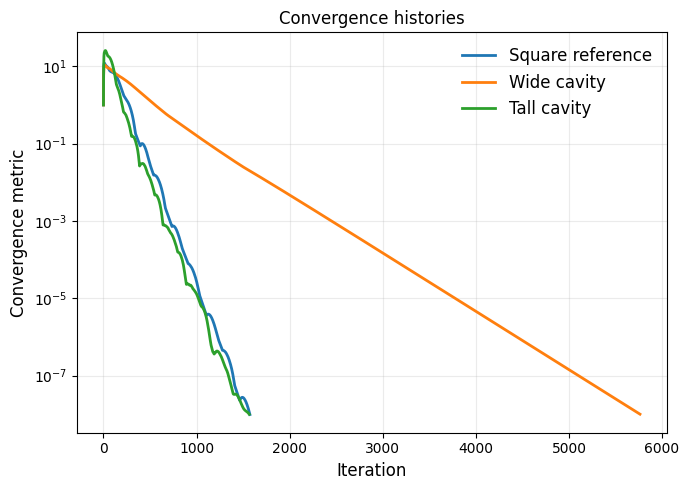

In [8]:
fig, ax = plt.subplots(figsize=(7, 5))

for result in results:
    history = result["conv_history"]
    ax.semilogy(history, linewidth=2, label=result["name"])

ax.set_xlabel("Iteration", fontsize=fontsize)
ax.set_ylabel("Convergence metric", fontsize=fontsize)
ax.set_title("Convergence histories", fontsize=fontsize)
ax.grid(True, which="both", alpha=0.25)
ax.legend(loc="best", fontsize=fontsize, frameon=False)
plt.tight_layout()
plt.savefig(plot_dir / "geometry_convergence_histories.png", dpi=300)
plt.show()

In [9]:
flow_metrics = pd.DataFrame([
    {
        "case": result["name"],
        "width (m)": result["width"],
        "height (m)": result["height"],
        "u_min": np.min(result["u"][:, :, 1]),
        "u_max": np.max(result["u"][:, :, 1]),
        "v_min": np.min(result["u"][:, :, 2]),
        "v_max": np.max(result["u"][:, :, 2]),
        "p_min": np.min(result["u"][:, :, 0]),
        "p_max": np.max(result["u"][:, :, 0]),
    }
    for result in results
])

flow_metrics.to_csv(plot_dir / "geometry_flow_metrics.csv", index=False)
flow_metrics

,case,width (m),height (m),u_min,u_max,v_min,v_max,p_min,p_max
0,Square reference,0.05,0.05,-0.196432,1.0,-0.336381,0.304372,-1.998526,4.196205
1,Wide cavity,0.10,0.05,-0.312247,1.0,-0.306857,0.288123,-3.522967,5.707682
2,Tall cavity,0.05,0.10,-0.160106,1.0,-0.304276,0.265023,-0.927204,3.051905
